# Task43 EZmock rawbox 手动标定

在下一格设置四个经验参数和运行选项，然后依次运行后面的单元格。`nreal` 控制每组参数取多少个 EZmock 的平均，手调时默认只算 1 个；图只在 notebook 中显示，不保存到磁盘。正式 covariance 生产必须另行使用 `FIX_AMPLITUDE=F`。

In [1]:
# ---------- 四个经验参数：主要手调这里 ----------
rho_c = 1.14
rho_exp = 5
pdf_base = 0.25
sigma_v = 0

# ---------- EZmock 生成设置：当前默认值 ----------
nreal = 10                 # 每组参数生成几个 realization 后取平均
box_size = 2000.0         # Mpc/h；当前 Abacus target 锁定为 2000
redshift = 0.725          # EZmock 输出红移
redshift_pk = 0.725       # 输入 linear P(k) 的红移
num_grid = 320            # EZmock density grid，每边网格数
num_tracer = 1297050      # 25 个 Abacus rawbox 的平均 halo 数量取整
fix_amplitude = True      # 标定必须 True；正式 covariance 必须 False
invert_phase = False
rand_generator = 1        # 0=MRG32k3a，1=MT19937
pk_interp_log = True
bao_enhance = 0.0
attach_particle = True
apply_rsd = False         # 当前 target 是 real space

# AbacusSummit base_c000 cosmology（当前输入谱锁定）
omega_m_non_neutrino = 0.3137721026737606
omega_nu = 0.0014197664745152646
de_eos_w = -1.0

# ---------- 测量与运行设置 ----------
pk_mesh_size = 400
pk_kmin, pk_kmax, pk_dk = 0.001, 0.3001, 0.002
xi_smin, xi_smax, xi_ds = 50.0, 550.0, 10.0
xi_plot_max = 250.0
threads = 8              # 登录节点最多 8 核
seed_base = 430100

In [2]:
import os
import subprocess
from pathlib import Path

ROOT = Path('/pscratch/sd/l/lzy/PNG-2PCF-model-to-observe')
RUNNER = ROOT / 'codes/task43/run_task43_ezmock_rawbox_trial_login.sh'
TARGET_NPZ = ROOT / 'outputs/task43_outputs/ezmock_rawbox_z0p725_mmin1p4e13/summary/task43_ezmock_rawbox_z0p725_mmin1p4e13_x25.npz'

def number_tag(value):
    return f'{float(value):.8g}'.replace('-', 'm').replace('+', '').replace('.', 'p')

def tf(value):
    return 'T' if bool(value) else 'F'

# 当前 target/输入谱的锁定条件；若以后要改这些，需要同步重建 target 或 linear P(k)。
assert box_size == 2000.0
assert redshift == redshift_pk == 0.725
assert fix_amplitude is True and apply_rsd is False
assert (omega_m_non_neutrino, omega_nu, de_eos_w) == (0.3137721026737606, 0.0014197664745152646, -1.0)
assert (pk_kmin, pk_kmax, pk_dk) == (0.001, 0.3001, 0.002)
assert (xi_smin, xi_smax, xi_ds) == (50.0, 550.0, 10.0)
assert 1 <= int(nreal) <= 25 and 1 <= int(threads) <= 8

label = (
    f'manual_Ng{num_grid}_Nt{num_tracer}_inv{tf(invert_phase)}_'
    f'rng{rand_generator}_bao{number_tag(bao_enhance)}_att{tf(attach_particle)}_'
    f'c{number_tag(rho_c)}_e{number_tag(rho_exp)}_b{number_tag(pdf_base)}_v{number_tag(sigma_v)}'
)
env = os.environ.copy()
env.update({
    'TASK43_EZMOCK_LABEL': label,
    'TASK43_EZMOCK_RHO_C': str(rho_c),
    'TASK43_EZMOCK_RHO_EXP': str(rho_exp),
    'TASK43_EZMOCK_PDF_BASE': str(pdf_base),
    'TASK43_EZMOCK_SIGMA_V': str(sigma_v),
    'TASK43_EZMOCK_NREAL': str(int(nreal)),
    'TASK43_EZMOCK_NGRID': str(int(num_grid)),
    'TASK43_EZMOCK_NTRACER': str(int(num_tracer)),
    'TASK43_EZMOCK_MESH_SIZE': str(int(pk_mesh_size)),
    'TASK43_EZMOCK_SEED_BASE': str(int(seed_base)),
    'TASK43_EZMOCK_RAND_GENERATOR': str(int(rand_generator)),
    'TASK43_EZMOCK_PK_INTERP_LOG': tf(pk_interp_log),
    'TASK43_EZMOCK_INVERT_PHASE': tf(invert_phase),
    'TASK43_EZMOCK_BAO_ENHANCE': str(float(bao_enhance)),
    'TASK43_EZMOCK_ATTACH_PARTICLE': tf(attach_particle),
    'TASK43_EZMOCK_CLASSIFICATION': 'manual_calibration',
    'TASK43_EZMOCK_XI_PLOT_MAX': str(float(xi_plot_max)),
    'TASK43_EZMOCK_COMPARISON_LABEL': 'Manual calibration',
    'TASK43_EZMOCK_SKIP_PLOT': '1',
    'TASK43_EZMOCK_THREADS': str(int(threads)),
})
subprocess.run(['bash', str(RUNNER)], cwd=ROOT, env=env, check=True)

SUMMARY_JSON = (
    ROOT / 'outputs/task43_outputs/ezmock_calibration_rawbox_z0p725_mmin1p4e13'
    / label / 'summary' / f'{label}_x{int(nreal)}_fixedamp_mean_2pcf_pk.json'
)
SUMMARY_NPZ = SUMMARY_JSON.with_suffix('.npz')
print(f'Finished: {label}')
print(f'Summary: {SUMMARY_NPZ}')

[skip] /pscratch/sd/l/lzy/PNG-2PCF-model-to-observe/outputs/task43_outputs/ezmock_calibration_rawbox_z0p725_mmin1p4e13/linear_pk/abacus_c000_linear_matter_pk_z0p725_desilike_cosmoprimo.dat
[trial] realization 1/10 seed=430101
[trial] realization 2/10 seed=430102
[trial] realization 3/10 seed=430103
[trial] realization 4/10 seed=430104
[trial] realization 5/10 seed=430105
[trial] realization 6/10 seed=430106
[trial] realization 7/10 seed=430107
[trial] realization 8/10 seed=430108
[trial] realization 9/10 seed=430109
[trial] realization 10/10 seed=430110
[done] summary=/pscratch/sd/l/lzy/PNG-2PCF-model-to-observe/outputs/task43_outputs/ezmock_calibration_rawbox_z0p725_mmin1p4e13/manual_Ng320_Nt1297050_invF_rng1_bao0_attT_c1p14_e5_b0p25_v0/summary/manual_Ng320_Nt1297050_invF_rng1_bao0_attT_c1p14_e5_b0p25_v0_x10_fixedamp_mean_2pcf_pk.npz
{
  "pk_fractional_delta_mean_k0p01_0p10": -0.004058486853897246,
  "pk_fractional_delta_rms_k0p01_0p10": 0.014951322834516622,
  "xi_absolute_delta_rms_

{
  "pk_fractional_delta_mean_k0p01_0p10": -0.004058486853897246,
  "pk_fractional_delta_rms_k0p01_0p10": 0.014951322834516622,
  "xi_absolute_delta_rms_s50_200": 0.00034802608857452855,
  "xi_delta_over_abacus_single_box_scatter_rms_s50_200": 0.7359045106900493
}


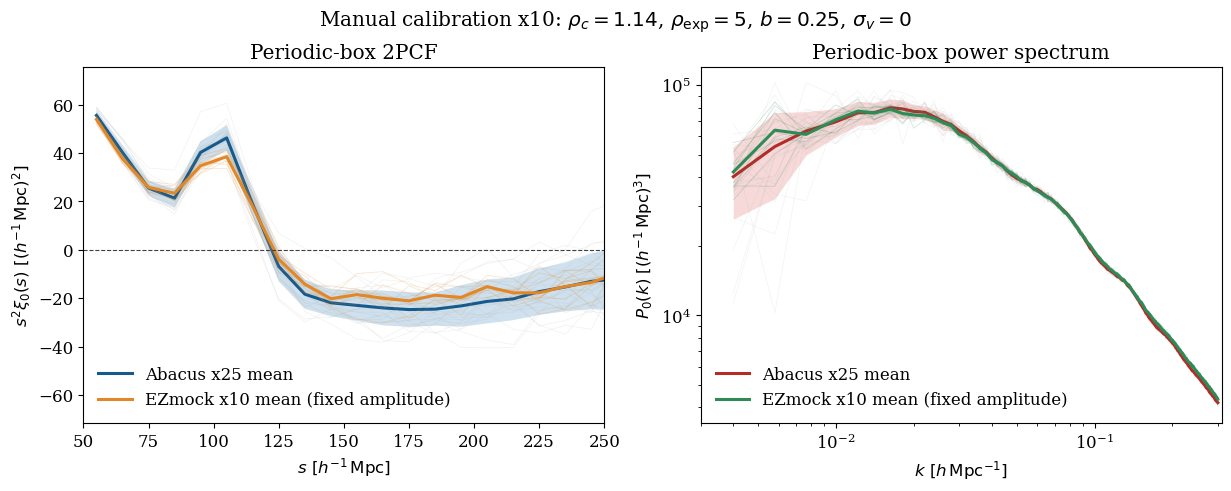

In [3]:
import json
import matplotlib.pyplot as plt
import numpy as np

result = json.loads(SUMMARY_JSON.read_text())
print(json.dumps(result['metrics'], indent=2, sort_keys=True))

with np.load(TARGET_NPZ, allow_pickle=False) as target:
    s = target['s'].astype(float)
    xi_target_all = target['xi0_all'].astype(float)
    xi_target = target['xi0_mean'].astype(float)
    xi_target_std = target['xi0_std'].astype(float)
    k = target['k'].astype(float)
    k_valid = target['k_valid_mask'].astype(bool)
    pk_target_all = target['pk0_all'].astype(float)
    pk_target = target['pk0_mean'].astype(float)
    pk_target_std = target['pk0_std'].astype(float)
with np.load(SUMMARY_NPZ, allow_pickle=False) as mock:
    xi_mock_all = mock['xi0_all'].astype(float)
    xi_mock = mock['xi0_mean'].astype(float)
    pk_mock_all = mock['pk0_all'].astype(float)
    pk_mock = mock['pk0_mean'].astype(float)
    k_valid &= mock['k_valid_mask'].astype(bool)
nmock = xi_mock_all.shape[0]

plt.rcParams.update({'font.family': 'serif', 'font.size': 12})
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.8), constrained_layout=True)
for row in xi_target_all:
    axes[0].plot(s, s**2 * row, color='0.7', lw=0.5, alpha=0.18)
axes[0].fill_between(s, s**2 * (xi_target - xi_target_std), s**2 * (xi_target + xi_target_std), color='#2878B5', alpha=0.22, lw=0)
axes[0].plot(s, s**2 * xi_target, color='#145A8D', lw=2.2, label='Abacus x25 mean')
for row in xi_mock_all:
    axes[0].plot(s, s**2 * row, color='#E18727', lw=0.65, alpha=0.20)
axes[0].plot(s, s**2 * xi_mock, color='#E18727', lw=2.2, label=f'EZmock x{nmock} mean (fixed amplitude)')
axes[0].axhline(0, color='0.25', lw=0.8, ls='--')
axes[0].set(xlim=(xi_smin, xi_plot_max), xlabel=r'$s\ [h^{-1}\,\mathrm{Mpc}]$', ylabel=r'$s^2\xi_0(s)\ [(h^{-1}\,\mathrm{Mpc})^2]$', title='Periodic-box 2PCF')
axes[0].legend(frameon=False)

for row in pk_target_all[:, k_valid]:
    axes[1].plot(k[k_valid], row, color='0.7', lw=0.5, alpha=0.16)
axes[1].fill_between(k[k_valid], (pk_target - pk_target_std)[k_valid], (pk_target + pk_target_std)[k_valid], color='#D9534F', alpha=0.22, lw=0)
axes[1].plot(k[k_valid], pk_target[k_valid], color='#B52B27', lw=2.2, label='Abacus x25 mean')
for row in pk_mock_all[:, k_valid]:
    axes[1].plot(k[k_valid], row, color='#2E8B57', lw=0.65, alpha=0.20)
axes[1].plot(k[k_valid], pk_mock[k_valid], color='#2E8B57', lw=2.2, label=f'EZmock x{nmock} mean (fixed amplitude)')
axes[1].set(xscale='log', yscale='log', xlim=(3e-3, 3.1e-1), xlabel=r'$k\ [h\,\mathrm{Mpc}^{-1}]$', ylabel=r'$P_0(k)\ [(h^{-1}\,\mathrm{Mpc})^3]$', title='Periodic-box power spectrum')
axes[1].legend(frameon=False, loc='lower left')
fig.suptitle(fr'Manual calibration x{nmock}: $\rho_c={rho_c:g}$, $\rho_{{\rm exp}}={rho_exp:g}$, $b={pdf_base:g}$, $\sigma_v={sigma_v:g}$')
plt.show()